In [1]:
import cv2
import numpy as np
import torch
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor
from skimage import segmentation

In [2]:
crop_settings_0 = np.load("/work/com-304/datasets/clevr_com_304/train/crop_settings/00001.npy")
path = "/scratch/tmaillar/rgb/train/point_50_view_0_domain_rgb.png"
rgb_img = Image.open(path).convert("RGB")

aug_idx = 1
x1, y1, x2, y2, flip = crop_settings_0[aug_idx]
top, left, h, w = y1, x1, (y2 - y1), (x2 - x1)
cropped = TF.crop(rgb_img, top, left, h, w)
resized = cropped.resize((256, 256), resample=Image.BILINEAR)
if flip:
    resized = TF.hflip(resized)

resized_numpy = np.array(resized)

In [3]:
def show_SAM(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    h, w = sorted_anns[0]['segmentation'].shape
    img = np.ones((h, w, 3))
    for ann in sorted_anns:
        m = ann['segmentation']
        img[m] = np.random.random(3)
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    
def show_SAM_Canny(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    h, w = sorted_anns[0]['segmentation'].shape
    img = np.ones((h, w, 3))
    LOW, HIGH = 100, 200
    for ann in sorted_anns:
        m = ann['segmentation']
        img[m] = np.random.random(3)
        mask_uint8 = (m * 255).astype(np.uint8)
        edges = cv2.Canny(mask_uint8, LOW, HIGH)
        r, c = np.where(edges > 0)
        img[r, c] = np.array([0, 0, 1]) # color lines in white
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

def SAM_to_Canny(anns, low=100, high=200):
    if len(anns) == 0:
        return None
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    h, w = sorted_anns[0]['segmentation'].shape
    binary = np.zeros((h, w), dtype=np.uint8)
    for ann in sorted_anns:
        m = ann['segmentation']
        mask_uint8 = (m * 255).astype(np.uint8)
        edges = cv2.Canny(mask_uint8, low, high)
        binary[edges > 0] = 255
    return binary

In [4]:
device = "cuda"
sam_checkpoint = "/scratch/tmaillar/sam_vit_h_4b8939.pth"
model_type = "default"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
mask_generator = SamAutomaticMaskGenerator(
    sam,
    pred_iou_thresh=0.88,     
    stability_score_thresh=0.95,
    min_mask_region_area=5000,    # default 0 
    points_per_side=15,          # default 32
)

masks = mask_generator.generate(resized_numpy)

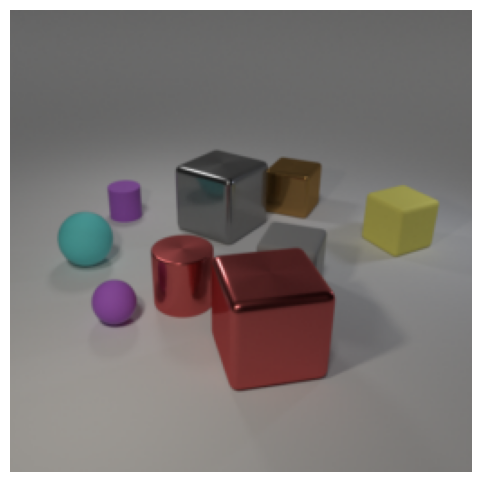

In [19]:
plt.figure(figsize=(6,6))
plt.imshow(resized)
plt.axis('off')
plt.show() 

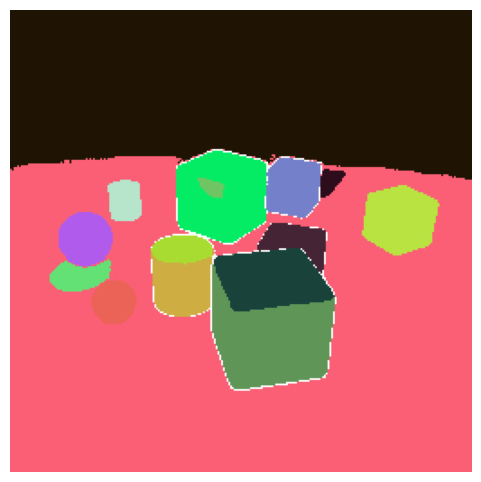

In [6]:
show_SAM(masks)

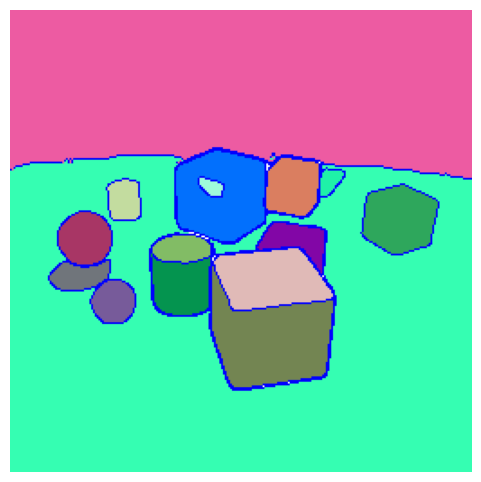

In [18]:
show_SAM_Canny(masks)

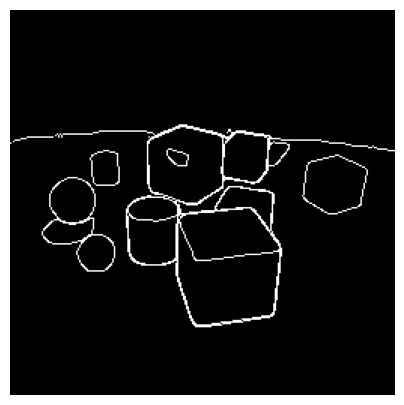

In [9]:
edges = SAM_to_Canny(masks)
plt.figure(figsize=(5, 5))
plt.imshow(edges, cmap='gray')
plt.axis('off')
plt.show()

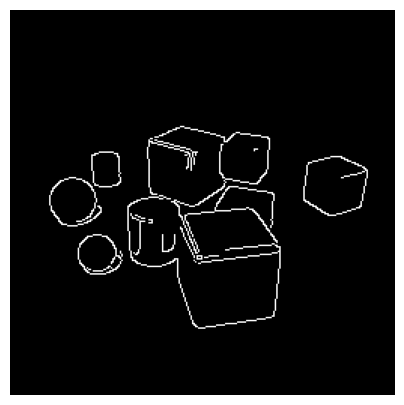

In [11]:
# no SAM, Canny only 
LOW = 100
HIGH = 200
no_SAM_edges = cv2.Canny(resized_numpy, LOW, HIGH)

plt.figure(figsize=(5, 5))
plt.imshow(no_SAM_edges, cmap='gray')
plt.axis('off')
plt.show()

In [12]:
from fourm.vq.vqvae import DiVAE
tok_edge_fourm = DiVAE.from_pretrained('EPFL-VILAB/4M_tokenizers_edge_8k_224-512').eval().to(device)

/home/tmaillar/.local/lib/python3.10/site-packages/fourm/vq/quantizers/quantize_lucid.py:263: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled = False)
/home/tmaillar/.local/lib/python3.10/site-packages/fourm/vq/quantizers/quantize_lucid.py:388: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled = False)


xFormers not available
xFormers not available


In [13]:
TARGET_SIZE = 256

edges_4m = cv2.resize(edges, (TARGET_SIZE, TARGET_SIZE))
edges_4m = edges_4m.astype(np.float32) / 255.0
edges_4m = edges_4m * 2.0 - 1.0

edges_4m = torch.tensor(edges_4m).unsqueeze(0).unsqueeze(0).to(device)
edges_4m.shape


torch.Size([1, 1, 256, 256])

In [14]:
with torch.no_grad():
    fourm_edge_tokens = tok_edge_fourm.tokenize(edges_4m)
fourm_edge_tokens.shape

/home/tmaillar/.local/lib/python3.10/site-packages/fourm/vq/models/vit_models.py:495: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled = False):


torch.Size([1, 16, 16])

In [15]:
with torch.no_grad():
    reconst_4m = tok_edge_fourm.decode_tokens(fourm_edge_tokens, image_size=TARGET_SIZE)
reconst_4m.shape

/home/tmaillar/.local/lib/python3.10/site-packages/fourm/vq/scheduling/diffusion_pipeline.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


torch.Size([1, 1, 256, 256])

In [16]:
img = reconst_4m[0]

img = img.squeeze(0)

img = img.clamp(-1, 1)
img = (img + 1) / 2
img_np = img.cpu().numpy()

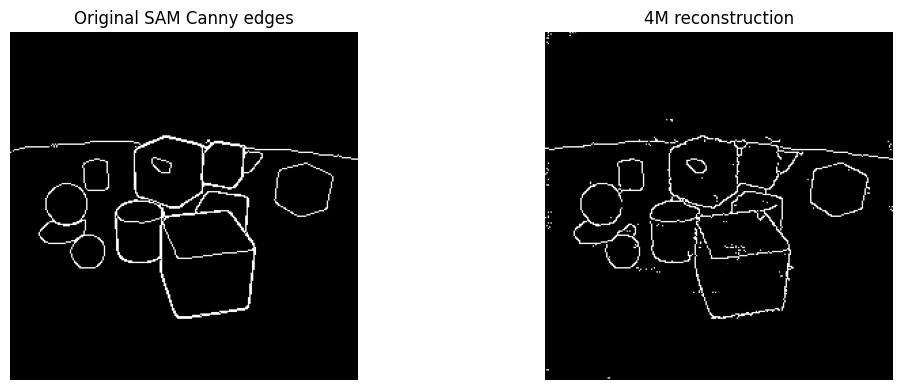

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(edges, cmap="gray")
axes[0].set_title("Original SAM Canny edges")
axes[0].axis("off")

axes[1].imshow(img_np, cmap="gray")
axes[1].set_title("4M reconstruction")
axes[1].axis("off")

plt.tight_layout()
plt.show()